<a href="https://www.kaggle.com/code/omborse771924/indian-packaged-food-nutritional-analysis-85-acc?scriptVersionId=343289927" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lalit7881/indian-packaged-foods-nutritional-dataset-2026/packaged_foods_india.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lalit7881/indian-packaged-foods-nutritional-dataset-2026/packaged_foods_india.csv')

In [3]:
df.head()

,S.No,Item name,Brand_Name,Category,Sub_Category,Ingredients,Serving_Size_g,Calories_kcal,Carbohydrates_g,Proteins_g,...,Dietary_Fiber_g,Cholesterol_mg,Calcium_mg,Vitamin,Iron_mg,Price_INR,Source_of_Data,Collection_Date,Collected_By,Remarks
0,1,HIDE & SEEK®,PARLE,BISCUIT,COOKIES,"REFINED WHEAT FLOUR (MAIDA), CHOCOLATE (23%) ...",100.0,479.0,73.4,5.9,...,0,0,0.0,0,0.0,30.0,ZEPTO,23-10-2025,NaN,NaN
1,2,Britannia Nutrichoice Digestive High-Fibre Bis...,BRITANNIA,BISCUIT,DIGESTIVE BISCUIT,"WHEAT FLOUR (ATTA) (65.5%), REFINED PALM OIL, ...",100.0,483.0,68.0,9.3,...,6.7,0.1,0.0,0,0.0,20.0,NaN,NaN,NaN,NaN
2,3,"Sunfeast Dark Fantasy Choco Fills, Original Fi...",SUNFEAST,BISCUIT,CHOCO FILLS,"SUGAR, REFINED PALMOLEIN, REFINED PALM OIL, C...",100.0,507.0,61.1,7.3,...,0,0.3,0.0,0,0.0,170.0,NaN,NaN,NaN,NaN
3,4,Sunfeast Baked Creations Rich Choco Chip Cookies,SUNFEAST,BISCUIT,COOKIES,"MAIDA (REFINED WHEAT FLOUR), DARK CHOCOLATE CH...",20.0,105.0,12.6,1.2,...,0,1,0.0,0,0.0,25.0,NaN,NaN,NaN,NaN
4,5,"sunfeast Dark Fantasy Bourbon, Classic Biscuit...",SUNFEAST,BISCUIT,CREAME,"Cocoa Solids (2.3%), Emulsifiers lecithin (fro...",108.0,445.0,77.4,9.1,...,0,0.1,0.0,"Vitamin B1 (mg) 0.3, Vitamin B2 (mg0 0.3, Vita...",2.9,35.0,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,S.No,Item name,Brand_Name,Category,Sub_Category,Ingredients,Serving_Size_g,Calories_kcal,Carbohydrates_g,Proteins_g,...,Dietary_Fiber_g,Cholesterol_mg,Calcium_mg,Vitamin,Iron_mg,Price_INR,Source_of_Data,Collection_Date,Collected_By,Remarks
847,848,Dairy Day Nutty Ice Cream Stick,DAIRY DAY,ICEREAMES,STICK,Outer Layer: Choco Compound Coating (25%) (Sug...,65.0,175.65,15.32,2.47,...,0,14,0.0,0,0.0,25.0,NaN,NaN,NaN,NaN
848,849,Grameen Dry Fruit Matka Kulfi Ice Cream Cup,GRAMEEN,ICEREAMES,KULFI,"Milk, Sugar, Pistachio, Almond, Cashew, and Pe...",100.0,240.91,26.01,7.21,...,0,0,0.0,0,0.0,190.0,NaN,NaN,NaN,NaN
849,850,Grameen Kesar Pista Kulfi Ice Cream Stick,GRAMEEN,ICEREAMES,KULFI,"Milk, Sugar, Pistachio and Saffron",70.0,154.00,16.10,4.1,...,5.7,21.3,0.0,0,0.0,75.0,NaN,NaN,NaN,NaN
850,851,Grameen Desi Malai Kulfi Ice Cream Stick,GRAMEEN,ICEREAMES,KULFI,"Milk,Sugar",70.0,155.00,18.30,4.5,...,0,10.1,0.0,0,0.0,70.0,NaN,NaN,NaN,NaN
851,852,Kwality Walls Cassata,KWALITY WALLS CADBUARY,ICEREAMES,CASSATA,"Water, Cake (16%) (Water, Refined Wheat Flour ...",65.0,157.00,19.70,3.5,...,0,0,0.0,0,0.0,70.0,NaN,NaN,NaN,NaN


In [5]:
df.info

<bound method DataFrame.info of      S.No                                          Item name  \
0       1                                      HIDE & SEEK®    
1       2  Britannia Nutrichoice Digestive High-Fibre Bis...   
2       3  Sunfeast Dark Fantasy Choco Fills, Original Fi...   
3       4   Sunfeast Baked Creations Rich Choco Chip Cookies   
4       5  sunfeast Dark Fantasy Bourbon, Classic Biscuit...   
..    ...                                                ...   
847   848                    Dairy Day Nutty Ice Cream Stick   
848   849        Grameen Dry Fruit Matka Kulfi Ice Cream Cup   
849   850          Grameen Kesar Pista Kulfi Ice Cream Stick   
850   851           Grameen Desi Malai Kulfi Ice Cream Stick   
851   852                              Kwality Walls Cassata   

                 Brand_Name   Category       Sub_Category  \
0                     PARLE    BISCUIT            COOKIES   
1                 BRITANNIA    BISCUIT  DIGESTIVE BISCUIT   
2               

In [6]:
df.describe

<bound method NDFrame.describe of      S.No                                          Item name  \
0       1                                      HIDE & SEEK®    
1       2  Britannia Nutrichoice Digestive High-Fibre Bis...   
2       3  Sunfeast Dark Fantasy Choco Fills, Original Fi...   
3       4   Sunfeast Baked Creations Rich Choco Chip Cookies   
4       5  sunfeast Dark Fantasy Bourbon, Classic Biscuit...   
..    ...                                                ...   
847   848                    Dairy Day Nutty Ice Cream Stick   
848   849        Grameen Dry Fruit Matka Kulfi Ice Cream Cup   
849   850          Grameen Kesar Pista Kulfi Ice Cream Stick   
850   851           Grameen Desi Malai Kulfi Ice Cream Stick   
851   852                              Kwality Walls Cassata   

                 Brand_Name   Category       Sub_Category  \
0                     PARLE    BISCUIT            COOKIES   
1                 BRITANNIA    BISCUIT  DIGESTIVE BISCUIT   
2             

In [7]:
df.isnull

<bound method DataFrame.isnull of      S.No                                          Item name  \
0       1                                      HIDE & SEEK®    
1       2  Britannia Nutrichoice Digestive High-Fibre Bis...   
2       3  Sunfeast Dark Fantasy Choco Fills, Original Fi...   
3       4   Sunfeast Baked Creations Rich Choco Chip Cookies   
4       5  sunfeast Dark Fantasy Bourbon, Classic Biscuit...   
..    ...                                                ...   
847   848                    Dairy Day Nutty Ice Cream Stick   
848   849        Grameen Dry Fruit Matka Kulfi Ice Cream Cup   
849   850          Grameen Kesar Pista Kulfi Ice Cream Stick   
850   851           Grameen Desi Malai Kulfi Ice Cream Stick   
851   852                              Kwality Walls Cassata   

                 Brand_Name   Category       Sub_Category  \
0                     PARLE    BISCUIT            COOKIES   
1                 BRITANNIA    BISCUIT  DIGESTIVE BISCUIT   
2             

In [8]:
df.isnull().sum()

S.No                 0
Item name            0
Brand_Name           0
Category             0
Sub_Category         0
Ingredients          0
Serving_Size_g       0
Calories_kcal        1
Carbohydrates_g      1
Proteins_g           1
Total_Fat_g          1
Saturated_Fat_g      3
Trans_Fat_g          3
Sugar_g              5
Sodium_mg            5
Dietary_Fiber_g      4
Cholesterol_mg      13
Calcium_mg           6
Vitamin              5
Iron_mg              7
Price_INR            7
Source_of_Data     850
Collection_Date    849
Collected_By       852
Remarks            852
dtype: int64

In [9]:
# ==========================================================
# CLEAN DATA + CONVERT NUMERIC COLUMNS + HANDLE NULL VALUES
# ==========================================================

import pandas as pd
import numpy as np

# Make a copy
data = df.copy()

# ==========================================================
# NUMERICAL COLUMNS
# ==========================================================

numeric_columns = [
    "Serving_Size_g",
    "Calories_kcal",
    "Carbohydrates_g",
    "Proteins_g",
    "Total_Fat_g",
    "Saturated_Fat_g",
    "Trans_Fat_g",
    "Sugar_g",
    "Sodium_mg",
    "Dietary_Fiber_g",
    "Cholesterol_mg",
    "Calcium_mg",
    "Iron_mg",
    "Price_INR"
]

# ==========================================================
# CLEAN NUMERICAL VALUES
# ==========================================================

for col in numeric_columns:

    # Convert everything to string first
    data[col] = data[col].astype(str).str.strip()

    # Replace comma decimal separator
    # Example: 7,65 -> 7.65
    data[col] = data[col].str.replace(
        ",",
        ".",
        regex=False
    )

    # Handle values such as <1
    # <1 becomes 1
    data[col] = data[col].str.replace(
        r"^<\s*",
        "",
        regex=True
    )

    # Convert invalid values to NaN
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

# ==========================================================
# HANDLE SPECIAL / CORRUPTED VALUES
# ==========================================================

# Any values that could not be converted are now NaN.
# Replace NaN with the median of that column.

for col in numeric_columns:

    median_value = data[col].median()

    data[col] = data[col].fillna(
        median_value
    )

# ==========================================================
# CATEGORICAL / TEXT COLUMNS
# ==========================================================

categorical_columns = [
    "Item name",
    "Brand_Name",
    "Category",
    "Sub_Category",
    "Ingredients",
    "Vitamin",
    "Source_of_Data",
    "Collected_By",
    "Remarks"
]

for col in categorical_columns:

    if data[col].notna().any():

        data[col] = data[col].fillna(
            data[col].mode()[0]
        )

# ==========================================================
# COLLECTION DATE
# ==========================================================

data["Collection_Date"] = pd.to_datetime(
    data["Collection_Date"],
    errors="coerce",
    dayfirst=True
)

# Fill missing dates with most frequent date
if data["Collection_Date"].notna().any():

    data["Collection_Date"] = data[
        "Collection_Date"
    ].fillna(
        data["Collection_Date"].mode()[0]
    )

# ==========================================================
# CHECK DATA TYPES
# ==========================================================

print("=" * 60)
print("DATA TYPES AFTER CONVERSION")
print("=" * 60)

print(data[numeric_columns].dtypes)

# ==========================================================
# CHECK NULL VALUES
# ==========================================================

print("\n" + "=" * 60)
print("NULL VALUES AFTER HANDLING")
print("=" * 60)

print(data.isnull().sum())

# ==========================================================
# TOTAL NULL VALUES
# ==========================================================

print("\nTotal remaining null values:")

print(
    data.isnull().sum().sum()
)

# ==========================================================
# CHECK NUMERIC DATA
# ==========================================================

print("\n" + "=" * 60)
print("NUMERICAL COLUMNS")
print("=" * 60)

print(
    data[numeric_columns].head()
)

# ==========================================================
# FINAL DATASET
# ==========================================================

df = data.copy()

print("\nData cleaning completed successfully!")

DATA TYPES AFTER CONVERSION
Serving_Size_g     float64
Calories_kcal      float64
Carbohydrates_g    float64
Proteins_g         float64
Total_Fat_g        float64
Saturated_Fat_g    float64
Trans_Fat_g        float64
Sugar_g            float64
Sodium_mg          float64
Dietary_Fiber_g    float64
Cholesterol_mg     float64
Calcium_mg         float64
Iron_mg            float64
Price_INR          float64
dtype: object

NULL VALUES AFTER HANDLING
S.No                 0
Item name            0
Brand_Name           0
Category             0
Sub_Category         0
Ingredients          0
Serving_Size_g       0
Calories_kcal        0
Carbohydrates_g      0
Proteins_g           0
Total_Fat_g          0
Saturated_Fat_g      0
Trans_Fat_g          0
Sugar_g              0
Sodium_mg            0
Dietary_Fiber_g      0
Cholesterol_mg       0
Calcium_mg           0
Vitamin              0
Iron_mg              0
Price_INR            0
Source_of_Data       0
Collection_Date      0
Collected_By       852


In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
847    False
848    False
849    False
850    False
851    False
Length: 852, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['S.No', 'Item name', 'Brand_Name', 'Category', 'Sub_Category',
       'Ingredients', 'Serving_Size_g', 'Calories_kcal', 'Carbohydrates_g',
       'Proteins_g', 'Total_Fat_g', 'Saturated_Fat_g', 'Trans_Fat_g',
       'Sugar_g', 'Sodium_mg', 'Dietary_Fiber_g', 'Cholesterol_mg',
       'Calcium_mg', 'Vitamin', 'Iron_mg', 'Price_INR', 'Source_of_Data',
       'Collection_Date', 'Collected_By', 'Remarks'],
      dtype='object')

## EDA

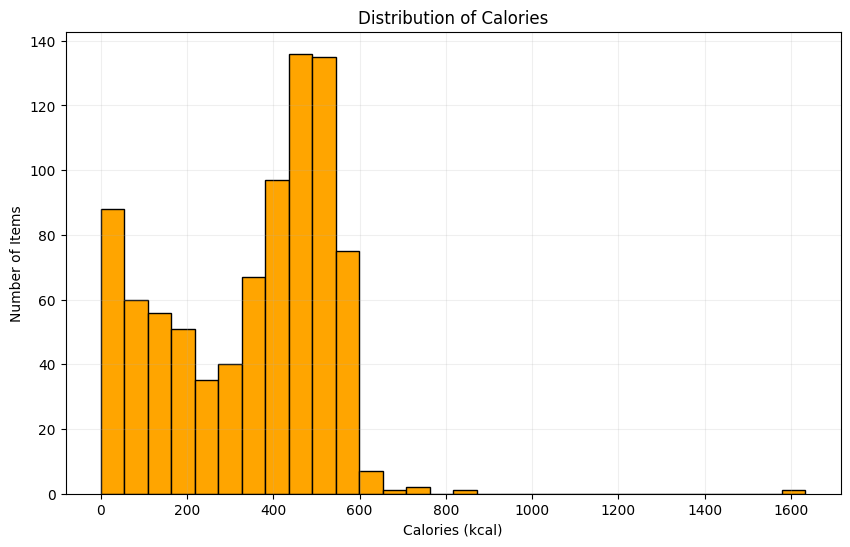

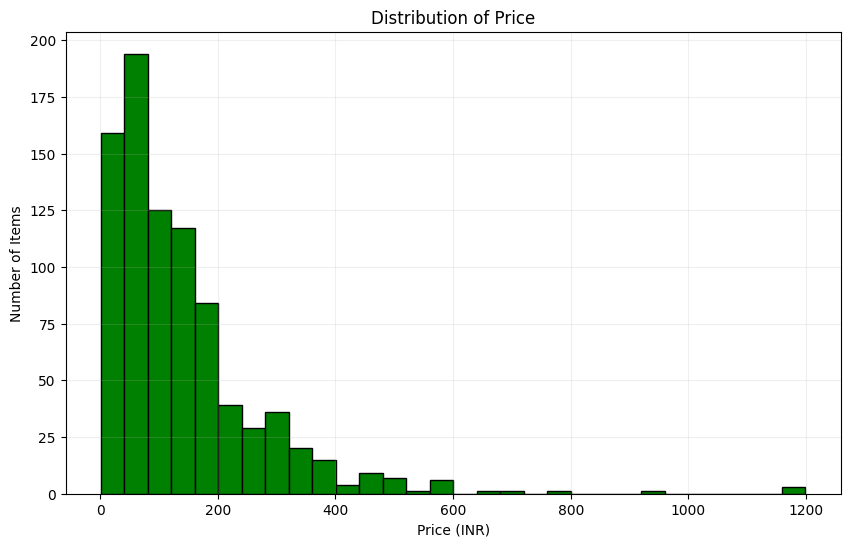

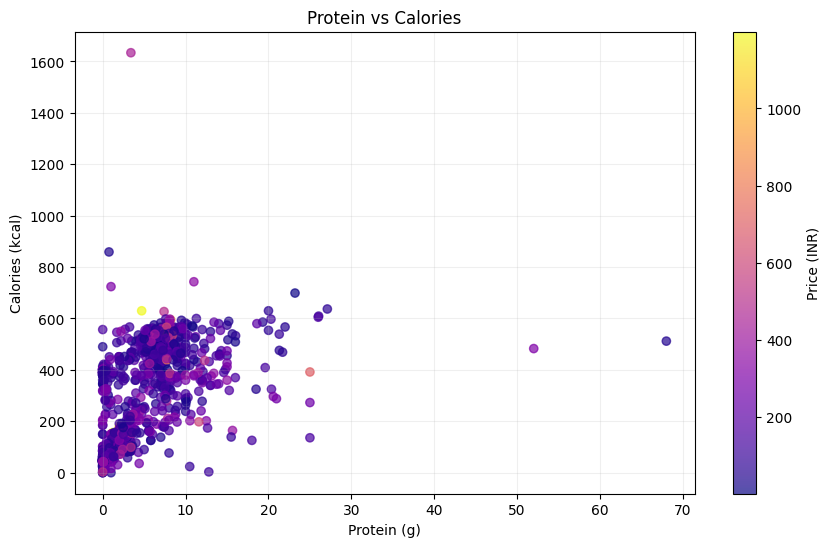

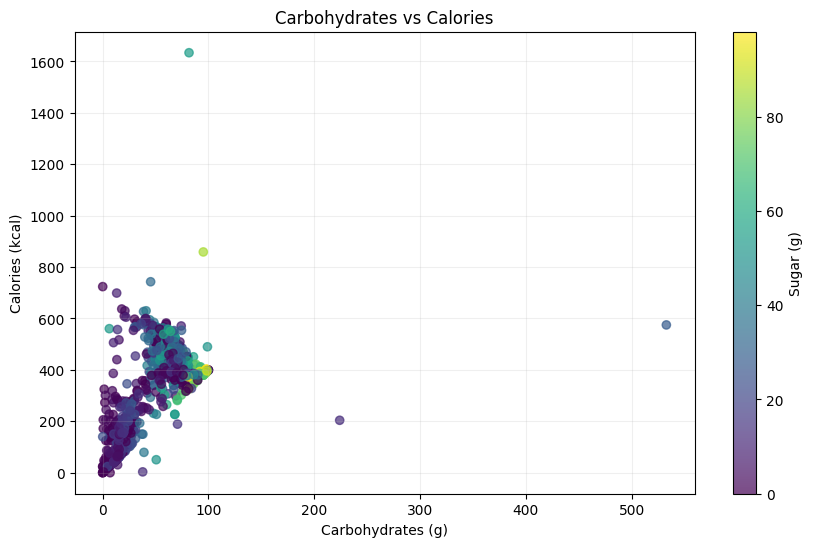

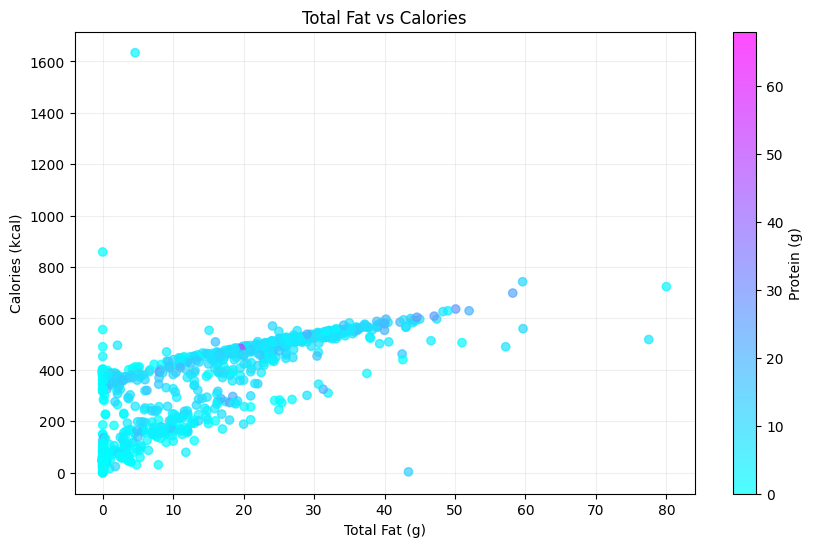

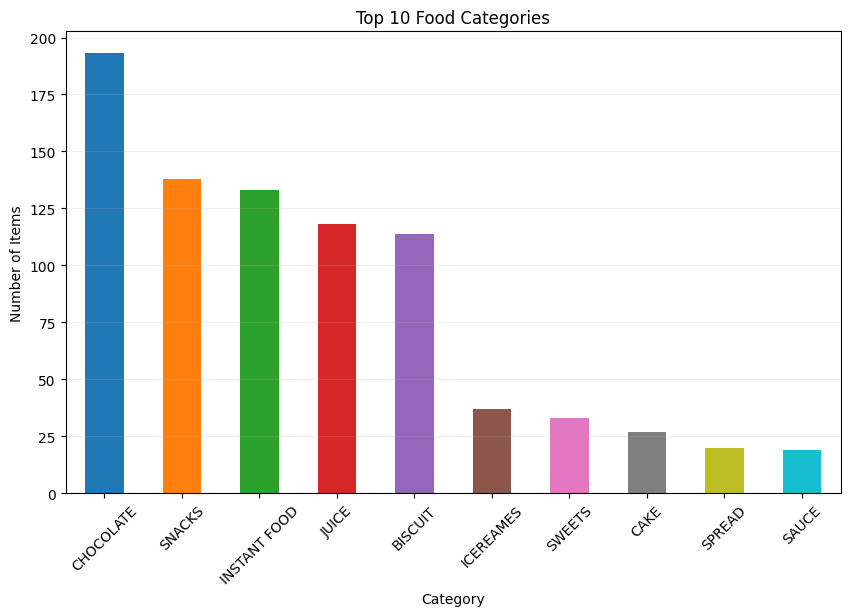

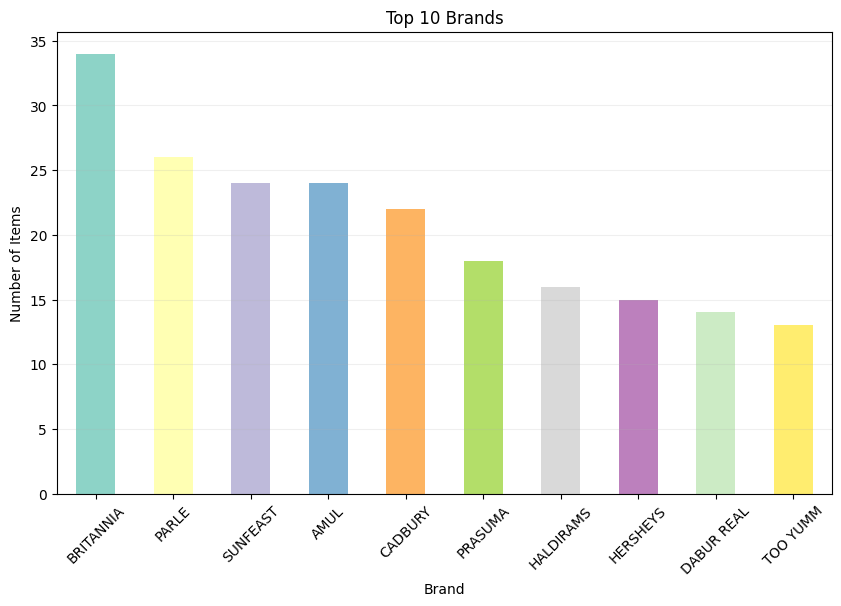

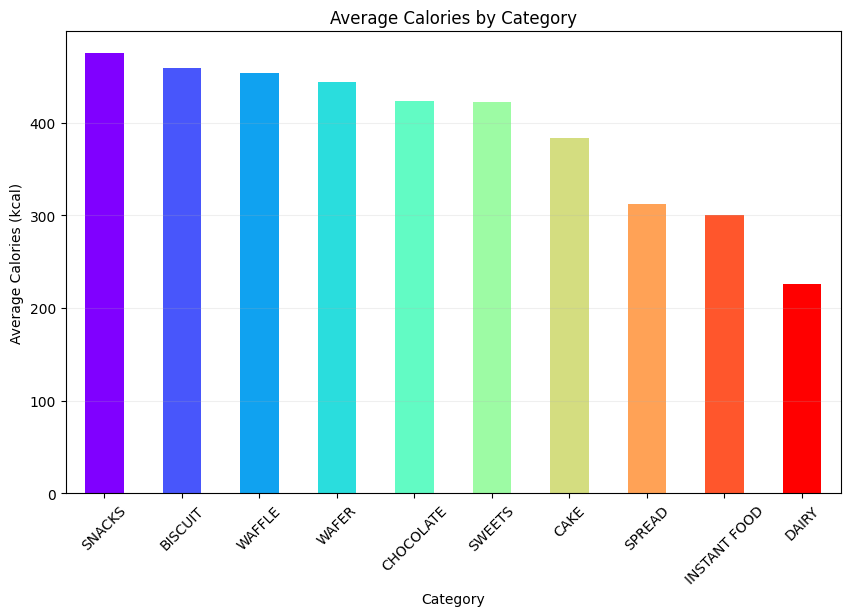

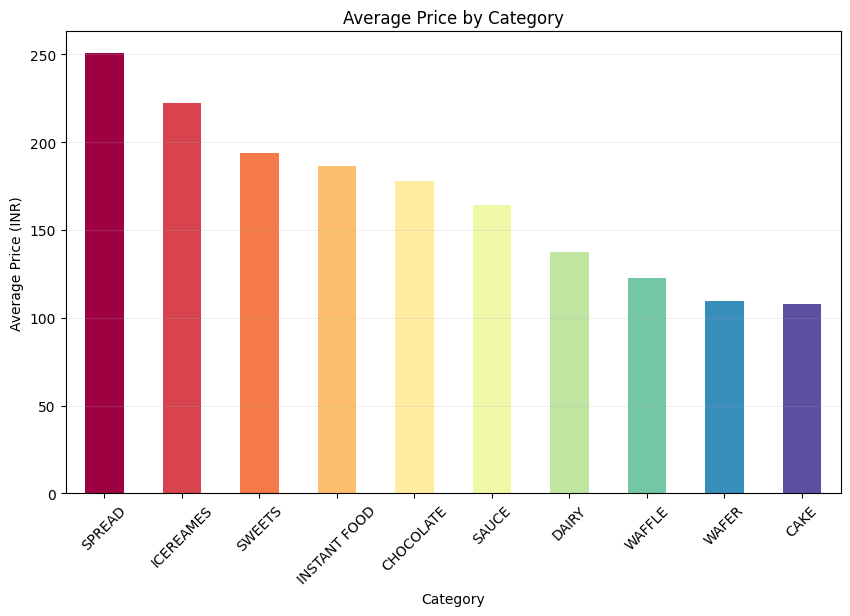

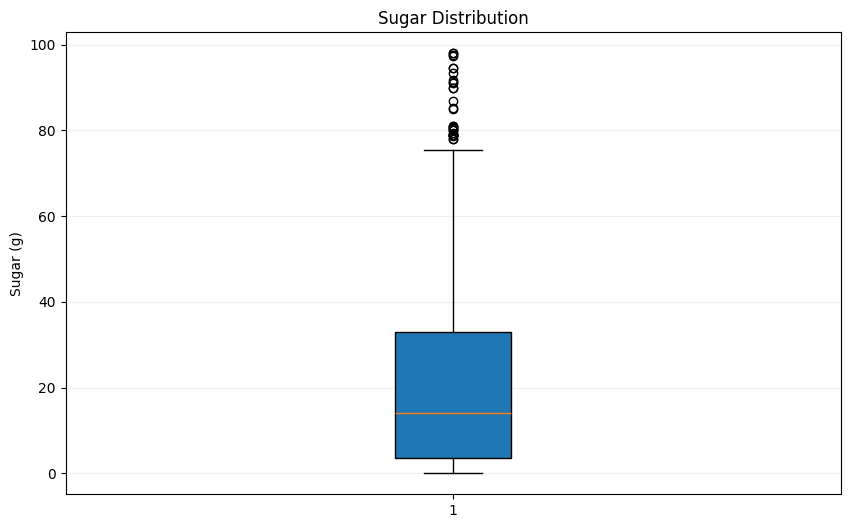

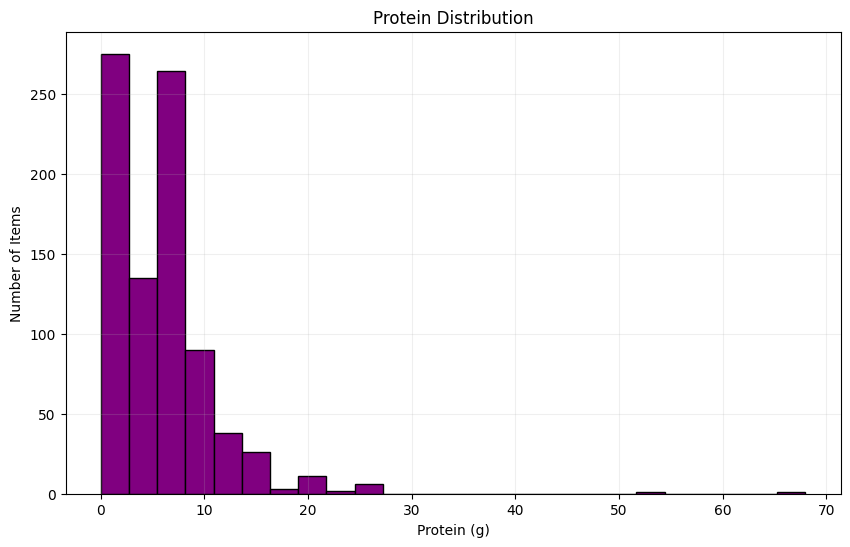

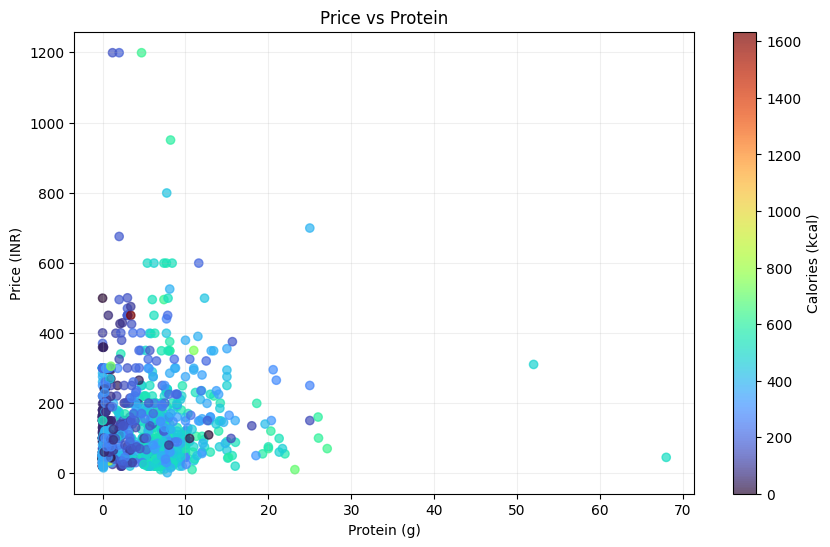

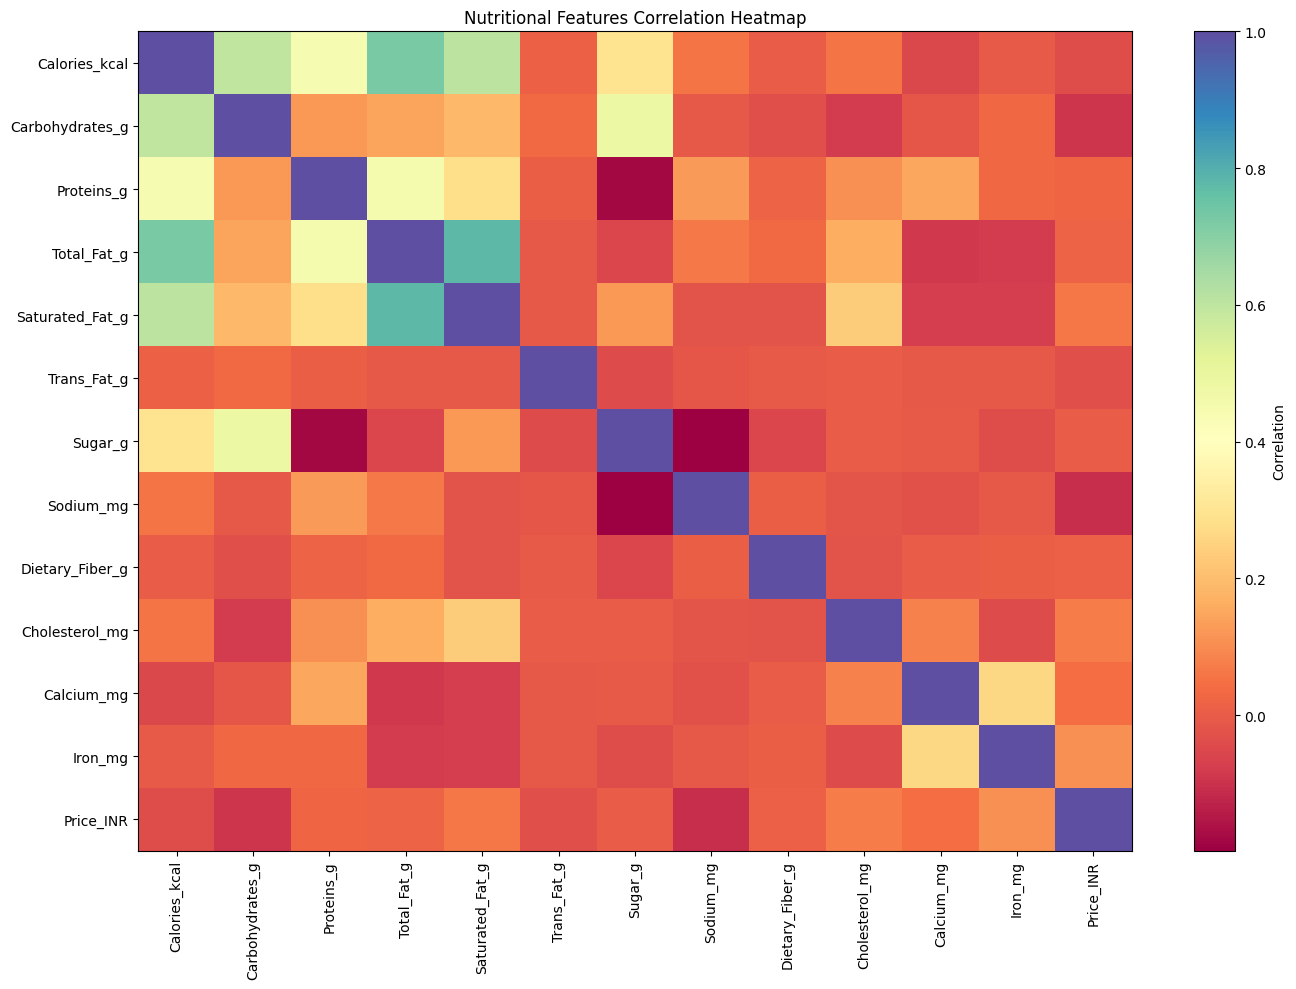

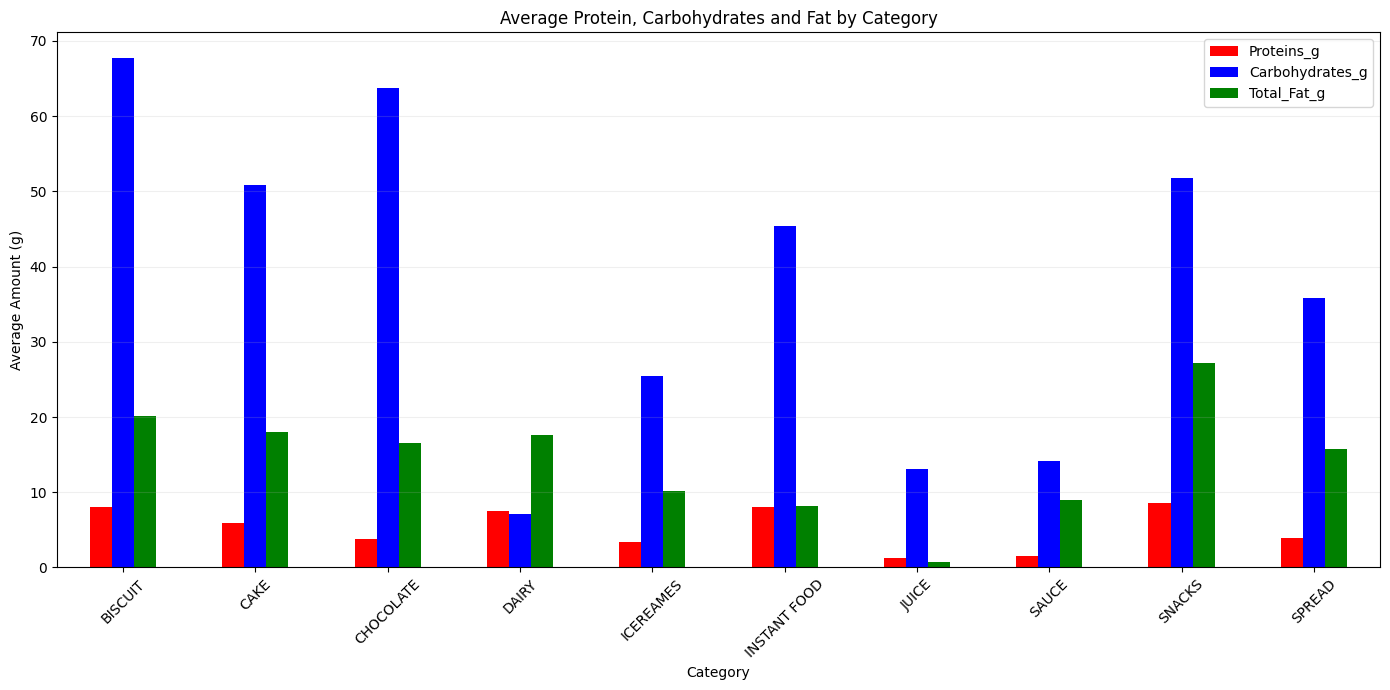

VISUALIZATION COMPLETED SUCCESSFULLY


In [13]:
# ==========================================================
# COMPLETE VISUALIZATION - MULTIPLE COLORS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

# ==========================================================
# DATE CONVERSION
# ==========================================================

data["Collection_Date"] = pd.to_datetime(
    data["Collection_Date"],
    errors="coerce",
    dayfirst=True
)

# ==========================================================
# NUMERICAL COLUMNS
# ==========================================================

numeric_cols = [
    "Serving_Size_g",
    "Calories_kcal",
    "Carbohydrates_g",
    "Proteins_g",
    "Total_Fat_g",
    "Saturated_Fat_g",
    "Trans_Fat_g",
    "Sugar_g",
    "Sodium_mg",
    "Dietary_Fiber_g",
    "Cholesterol_mg",
    "Calcium_mg",
    "Iron_mg",
    "Price_INR"
]

# Convert numeric columns safely
for col in numeric_cols:

    data[col] = (
        data[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(r"^<\s*", "", regex=True)
    )

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

# Fill numeric missing values
for col in numeric_cols:

    data[col] = data[col].fillna(
        data[col].median()
    )

# ==========================================================
# SETUP
# ==========================================================

plt.rcParams["figure.figsize"] = (10, 6)

# ==========================================================
# 1. CALORIES DISTRIBUTION
# ==========================================================

plt.figure()

plt.hist(
    data["Calories_kcal"],
    bins=30,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Calories")
plt.xlabel("Calories (kcal)")
plt.ylabel("Number of Items")
plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 2. PRICE DISTRIBUTION
# ==========================================================

plt.figure()

plt.hist(
    data["Price_INR"],
    bins=30,
    color="green",
    edgecolor="black"
)

plt.title("Distribution of Price")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Items")
plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 3. PROTEIN vs CALORIES
# ==========================================================

plt.figure()

plt.scatter(
    data["Proteins_g"],
    data["Calories_kcal"],
    c=data["Price_INR"],
    cmap="plasma",
    alpha=0.7
)

plt.colorbar(
    label="Price (INR)"
)

plt.title("Protein vs Calories")
plt.xlabel("Protein (g)")
plt.ylabel("Calories (kcal)")
plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 4. CARBOHYDRATES vs CALORIES
# ==========================================================

plt.figure()

plt.scatter(
    data["Carbohydrates_g"],
    data["Calories_kcal"],
    c=data["Sugar_g"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(
    label="Sugar (g)"
)

plt.title("Carbohydrates vs Calories")
plt.xlabel("Carbohydrates (g)")
plt.ylabel("Calories (kcal)")
plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 5. FAT vs CALORIES
# ==========================================================

plt.figure()

plt.scatter(
    data["Total_Fat_g"],
    data["Calories_kcal"],
    c=data["Proteins_g"],
    cmap="cool",
    alpha=0.7
)

plt.colorbar(
    label="Protein (g)"
)

plt.title("Total Fat vs Calories")
plt.xlabel("Total Fat (g)")
plt.ylabel("Calories (kcal)")
plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 6. TOP CATEGORIES
# ==========================================================

category_counts = (
    data["Category"]
    .value_counts()
    .head(10)
)

plt.figure()

category_counts.plot(
    kind="bar",
    color=plt.cm.tab10(
        np.linspace(
            0,
            1,
            len(category_counts)
        )
    )
)

plt.title("Top 10 Food Categories")
plt.xlabel("Category")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)

plt.show()

# ==========================================================
# 7. TOP BRANDS
# ==========================================================

brand_counts = (
    data["Brand_Name"]
    .value_counts()
    .head(10)
)

plt.figure()

brand_counts.plot(
    kind="bar",
    color=plt.cm.Set3(
        np.linspace(
            0,
            1,
            len(brand_counts)
        )
    )
)

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)

plt.show()

# ==========================================================
# 8. AVERAGE CALORIES BY CATEGORY
# ==========================================================

category_calories = (
    data.groupby("Category")["Calories_kcal"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()

category_calories.plot(
    kind="bar",
    color=plt.cm.rainbow(
        np.linspace(
            0,
            1,
            len(category_calories)
        )
    )
)

plt.title("Average Calories by Category")
plt.xlabel("Category")
plt.ylabel("Average Calories (kcal)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)

plt.show()

# ==========================================================
# 9. AVERAGE PRICE BY CATEGORY
# ==========================================================

category_price = (
    data.groupby("Category")["Price_INR"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()

category_price.plot(
    kind="bar",
    color=plt.cm.Spectral(
        np.linspace(
            0,
            1,
            len(category_price)
        )
    )
)

plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)

plt.show()

# ==========================================================
# 10. SUGAR DISTRIBUTION
# ==========================================================

plt.figure()

plt.boxplot(
    data["Sugar_g"].dropna(),
    patch_artist=True
)

plt.title("Sugar Distribution")
plt.ylabel("Sugar (g)")
plt.grid(axis="y", alpha=0.2)

plt.show()

# ==========================================================
# 11. PROTEIN DISTRIBUTION
# ==========================================================

plt.figure()

plt.hist(
    data["Proteins_g"],
    bins=25,
    color="purple",
    edgecolor="black"
)

plt.title("Protein Distribution")
plt.xlabel("Protein (g)")
plt.ylabel("Number of Items")
plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 12. PRICE vs PROTEIN
# ==========================================================

plt.figure()

plt.scatter(
    data["Proteins_g"],
    data["Price_INR"],
    c=data["Calories_kcal"],
    cmap="turbo",
    alpha=0.7
)

plt.colorbar(
    label="Calories (kcal)"
)

plt.title("Price vs Protein")
plt.xlabel("Protein (g)")
plt.ylabel("Price (INR)")
plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# 13. NUTRITIONAL CORRELATION HEATMAP
# ==========================================================

correlation_cols = [
    "Calories_kcal",
    "Carbohydrates_g",
    "Proteins_g",
    "Total_Fat_g",
    "Saturated_Fat_g",
    "Trans_Fat_g",
    "Sugar_g",
    "Sodium_mg",
    "Dietary_Fiber_g",
    "Cholesterol_mg",
    "Calcium_mg",
    "Iron_mg",
    "Price_INR"
]

corr = data[correlation_cols].corr()

plt.figure(figsize=(14, 10))

plt.imshow(
    corr,
    cmap="Spectral",
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Nutritional Features Correlation Heatmap"
)

plt.tight_layout()

plt.show()

# ==========================================================
# 14. AVERAGE NUTRITION BY CATEGORY
# ==========================================================

nutrition_category = (
    data.groupby("Category")[
        [
            "Proteins_g",
            "Carbohydrates_g",
            "Total_Fat_g"
        ]
    ]
    .mean()
    .head(10)
)

nutrition_category.plot(
    kind="bar",
    figsize=(14, 7),
    color=[
        "red",
        "blue",
        "green"
    ]
)

plt.title(
    "Average Protein, Carbohydrates and Fat by Category"
)

plt.xlabel("Category")
plt.ylabel("Average Amount (g)")
plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

print("==========================================")
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("==========================================")

## Features Engineering


CLASSIFICATION

Training samples: 681
Testing samples: 171

CLASSIFICATION ACCURACY
Accuracy: 0.8538
Accuracy (%): 85.38 %

Classification Report:
              precision    recall  f1-score   support

     BISCUIT       0.76      0.96      0.85        23
        CAKE       0.80      0.80      0.80         5
   CHOCOLATE       0.92      0.85      0.88        39
       DAIRY       1.00      0.50      0.67         2
   ICEREAMES       0.83      0.71      0.77         7
INSTANT FOOD       0.85      0.85      0.85        27
       JUICE       0.89      1.00      0.94        24
       SAUCE       0.75      0.75      0.75         4
      SNACKS       0.88      0.82      0.85        28
      SPREAD       1.00      0.50      0.67         4
      SWEETS       0.83      0.71      0.77         7
       WAFER       0.00      0.00      0.00         0
      WAFFLE       1.00      1.00      1.00         1

    accuracy                           0.85       171
   macro avg       0.81      0.73      0.

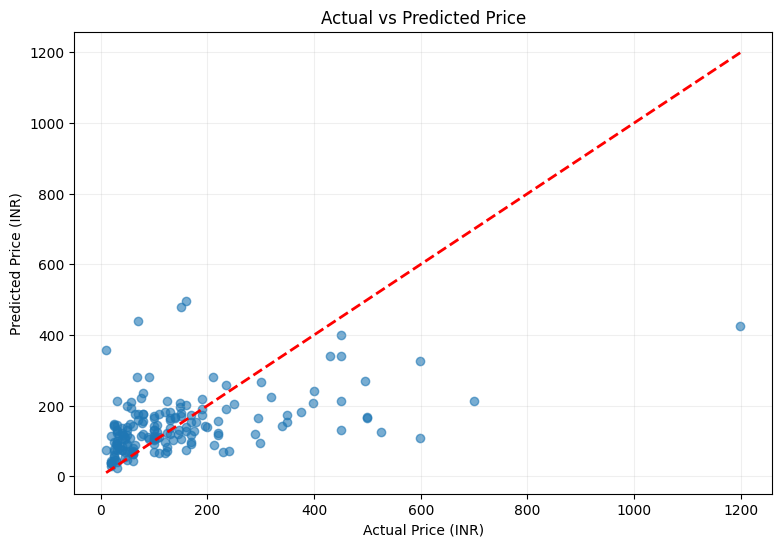


FINAL MODEL SUMMARY
Classification Accuracy : 85.38%
Regression R² Score     : 0.2177
Regression MAE          : 88.6161
Regression RMSE         : 138.0484


In [14]:
# ==========================================================
# FOOD DATASET
# FEATURE ENGINEERING + TRAIN/TEST + CLASSIFICATION
# + ACCURACY + REGRESSION + R2
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

# ==========================================================
# NUMERICAL COLUMNS
# ==========================================================

numeric_cols = [
    "Serving_Size_g",
    "Calories_kcal",
    "Carbohydrates_g",
    "Proteins_g",
    "Total_Fat_g",
    "Saturated_Fat_g",
    "Trans_Fat_g",
    "Sugar_g",
    "Sodium_mg",
    "Dietary_Fiber_g",
    "Cholesterol_mg",
    "Calcium_mg",
    "Iron_mg",
    "Price_INR"
]

# ==========================================================
# CONVERT NUMERIC COLUMNS
# ==========================================================

for col in numeric_cols:

    data[col] = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
        .str.replace(r"^<\s*", "", regex=True)
    )

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

# ==========================================================
# HANDLE NUMERIC NULL VALUES
# ==========================================================

for col in numeric_cols:

    data[col] = data[col].fillna(
        data[col].median()
    )

# ==========================================================
# HANDLE CATEGORICAL NULL VALUES
# ==========================================================

categorical_cols = [
    "Item name",
    "Brand_Name",
    "Category",
    "Sub_Category",
    "Ingredients",
    "Vitamin",
    "Source_of_Data",
    "Collected_By",
    "Remarks"
]

for col in categorical_cols:

    if col in data.columns:

        if data[col].notna().any():

            data[col] = data[col].fillna(
                data[col].mode()[0]
            )

# ==========================================================
# DATE FEATURE ENGINEERING
# ==========================================================

data["Collection_Date"] = pd.to_datetime(
    data["Collection_Date"],
    errors="coerce",
    dayfirst=True
)

data["Collection_Year"] = (
    data["Collection_Date"].dt.year
)

data["Collection_Month"] = (
    data["Collection_Date"].dt.month
)

data["Collection_Day"] = (
    data["Collection_Date"].dt.day
)

data["Collection_DayOfWeek"] = (
    data["Collection_Date"].dt.dayofweek
)

# Fill date feature missing values
for col in [
    "Collection_Year",
    "Collection_Month",
    "Collection_Day",
    "Collection_DayOfWeek"
]:

    data[col] = data[col].fillna(
        data[col].median()
    )

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Total macronutrients
data["Total_Macros_g"] = (
    data["Carbohydrates_g"]
    + data["Proteins_g"]
    + data["Total_Fat_g"]
)

# Total fat including saturated and trans fat
data["Unsaturated_Fat_g"] = (
    data["Total_Fat_g"]
    - data["Saturated_Fat_g"]
    - data["Trans_Fat_g"]
)

data["Unsaturated_Fat_g"] = (
    data["Unsaturated_Fat_g"]
    .clip(lower=0)
)

# Protein percentage of total macros
data["Protein_Ratio"] = (
    data["Proteins_g"]
    / (data["Total_Macros_g"] + 1)
)

# Carbohydrate percentage
data["Carb_Ratio"] = (
    data["Carbohydrates_g"]
    / (data["Total_Macros_g"] + 1)
)

# Fat percentage
data["Fat_Ratio"] = (
    data["Total_Fat_g"]
    / (data["Total_Macros_g"] + 1)
)

# Sugar to carbohydrate ratio
data["Sugar_Carb_Ratio"] = (
    data["Sugar_g"]
    / (data["Carbohydrates_g"] + 1)
)

# Fiber to carbohydrate ratio
data["Fiber_Carb_Ratio"] = (
    data["Dietary_Fiber_g"]
    / (data["Carbohydrates_g"] + 1)
)

# Calories per gram
data["Calories_per_gram"] = (
    data["Calories_kcal"]
    / (data["Serving_Size_g"] + 1)
)

# Protein per 100g
data["Protein_per_100g"] = (
    data["Proteins_g"]
    / (data["Serving_Size_g"] + 1)
) * 100

# Sugar per 100g
data["Sugar_per_100g"] = (
    data["Sugar_g"]
    / (data["Serving_Size_g"] + 1)
) * 100

# ==========================================================
# REMOVE ORIGINAL DATE
# ==========================================================

data.drop(
    columns=["Collection_Date"],
    inplace=True,
    errors="ignore"
)

# ==========================================================
# REMOVE ID COLUMN
# ==========================================================

data.drop(
    columns=["S.No"],
    inplace=True,
    errors="ignore"
)

# ==========================================================
# ==========================================================
# PART 1 - CLASSIFICATION
# TARGET = CATEGORY
# ==========================================================
# ==========================================================

print("=" * 70)
print("CLASSIFICATION")
print("=" * 70)

target_class = "Category"

X_class = data.drop(
    columns=[target_class]
)

y_class = data[target_class].astype(str)

# ==========================================================
# REMOVE HIGH-CARDINALITY TEXT COLUMNS
# ==========================================================

X_class.drop(
    columns=[
        "Item name",
        "Ingredients",
        "Remarks"
    ],
    inplace=True,
    errors="ignore"
)

# ==========================================================
# LABEL ENCODING
# ==========================================================

# Encode categorical feature columns
categorical_features = X_class.select_dtypes(
    include="object"
).columns

feature_encoders = {}

for col in categorical_features:

    le = LabelEncoder()

    X_class[col] = le.fit_transform(
        X_class[col].astype(str)
    )

    feature_encoders[col] = le

# ==========================================================
# TARGET ENCODING
# ==========================================================

target_encoder = LabelEncoder()

y_class_encoded = target_encoder.fit_transform(
    y_class
)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

class_counts = pd.Series(
    y_class_encoded
).value_counts()

# Stratification only if every class has >= 2 samples
if class_counts.min() >= 2:

    X_train_c, X_test_c, y_train_c, y_test_c = (
        train_test_split(
            X_class,
            y_class_encoded,
            test_size=0.20,
            random_state=42,
            stratify=y_class_encoded
        )
    )

else:

    X_train_c, X_test_c, y_train_c, y_test_c = (
        train_test_split(
            X_class,
            y_class_encoded,
            test_size=0.20,
            random_state=42
        )
    )

print("\nTraining samples:",
      len(X_train_c))

print("Testing samples:",
      len(X_test_c))

# ==========================================================
# RANDOM FOREST CLASSIFIER
# ==========================================================

classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

classifier.fit(
    X_train_c,
    y_train_c
)

# ==========================================================
# PREDICTION
# ==========================================================

y_pred_c = classifier.predict(
    X_test_c
)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test_c,
    y_pred_c
)

print("\n" + "=" * 50)
print("CLASSIFICATION ACCURACY")
print("=" * 50)

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Accuracy (%):",
    round(accuracy * 100, 2),
    "%"
)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test_c,
        y_pred_c,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_c,
        y_pred_c
    )
)

# ==========================================================
# CLASSIFICATION FEATURE IMPORTANCE
# ==========================================================

classification_importance = pd.DataFrame({

    "Feature": X_train_c.columns,

    "Importance":
        classifier.feature_importances_

})

classification_importance = (
    classification_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("\nTop Classification Features:")

print(
    classification_importance.head(15)
)

# ==========================================================
# ==========================================================
# PART 2 - REGRESSION
# TARGET = PRICE_INR
# ==========================================================
# ==========================================================

print("\n" + "=" * 70)
print("REGRESSION")
print("=" * 70)

target_reg = "Price_INR"

X_reg = data.drop(
    columns=[target_reg]
)

y_reg = data[target_reg]

# ==========================================================
# REMOVE HIGH-CARDINALITY TEXT
# ==========================================================

X_reg.drop(
    columns=[
        "Item name",
        "Ingredients",
        "Remarks"
    ],
    inplace=True,
    errors="ignore"
)

# ==========================================================
# ENCODE CATEGORICAL FEATURES
# ==========================================================

categorical_reg = X_reg.select_dtypes(
    include="object"
).columns

reg_encoders = {}

for col in categorical_reg:

    le = LabelEncoder()

    X_reg[col] = le.fit_transform(
        X_reg[col].astype(str)
    )

    reg_encoders[col] = le

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train_r, X_test_r, y_train_r, y_test_r = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)

print(
    "\nRegression training samples:",
    len(X_train_r)
)

print(
    "Regression testing samples:",
    len(X_test_r)
)

# ==========================================================
# RANDOM FOREST REGRESSOR
# ==========================================================

regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

regressor.fit(
    X_train_r,
    y_train_r
)

# ==========================================================
# PREDICTION
# ==========================================================

y_pred_r = regressor.predict(
    X_test_r
)

# ==========================================================
# R2 SCORE
# ==========================================================

r2 = r2_score(
    y_test_r,
    y_pred_r
)

mae = mean_absolute_error(
    y_test_r,
    y_pred_r
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_r,
        y_pred_r
    )
)

print("\n" + "=" * 50)
print("REGRESSION RESULTS")
print("=" * 50)

print(
    "R² Score:",
    round(r2, 4)
)

print(
    "MAE:",
    round(mae, 4)
)

print(
    "RMSE:",
    round(rmse, 4)
)

# ==========================================================
# REGRESSION FEATURE IMPORTANCE
# ==========================================================

regression_importance = pd.DataFrame({

    "Feature": X_train_r.columns,

    "Importance":
        regressor.feature_importances_

})

regression_importance = (
    regression_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("\nTop Regression Features:")

print(
    regression_importance.head(15)
)

# ==========================================================
# ACTUAL VS PREDICTED PRICE
# ==========================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_r,
    y_pred_r,
    alpha=0.6
)

min_value = min(
    y_test_r.min(),
    y_pred_r.min()
)

max_value = max(
    y_test_r.max(),
    y_pred_r.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")

plt.title(
    "Actual vs Predicted Price"
)

plt.grid(alpha=0.2)

plt.show()

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(
    f"Classification Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Regression R² Score     : {r2:.4f}"
)

print(
    f"Regression MAE          : {mae:.4f}"
)

print(
    f"Regression RMSE         : {rmse:.4f}"
)

## Thanks........Please Upvote